# Held-Out Backbone Comparison

Compare the four backbone families using the held-out test records produced by `evaluate_checkpoint` in `init_experiment.py`. The primary endpoint is **Test Micro F1**. Paired comparisons hold router, expert, and final seed fixed and use Wilcoxon signed-rank tests with Benjamini-Hochberg correction.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from init_experiment import (
    add_model_component_columns,
    build_component_delta_table,
    normalize_backbone_label,
    run_paired_component_tests,
    summarize_component_performance,
)

c:\1SCHOOL\grad\12-IS_S26\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RESULTS_DIR = Path('./results')
RESULT_GLOB = 'test_*__seed-*.json'
BACKBONE_ORDER = ['MobileNet Large', 'ConvNeXt Tiny', 'JE MobileNet Large', 'JE ConvNeXt Tiny']
BASELINE_BACKBONE = 'MobileNet Large'
PAIR_COLUMNS = ['Router', 'Expert', 'Final Seed']

result_paths = sorted(RESULTS_DIR.glob(RESULT_GLOB))
if not result_paths:
    raise FileNotFoundError(f'No held-out test JSON files matched {RESULTS_DIR / RESULT_GLOB}.')
records = []
for path in result_paths:
    with path.open(encoding='utf-8') as handle:
        record = json.load(handle)
    record['Result File'] = str(path)
    records.append(record)

results_df = pd.DataFrame(records)
required = {'Model', 'Final Seed', 'Test Micro F1'}
missing = required.difference(results_df.columns)
if missing:
    raise ValueError(f'Result records are missing required fields: {sorted(missing)}')
results_df = add_model_component_columns(results_df)
results_df['Backbone'] = results_df['Generalist'].map(normalize_backbone_label)
results_df = results_df[results_df['Backbone'].isin(BACKBONE_ORDER)].copy()
results_df['Backbone'] = pd.Categorical(results_df['Backbone'], BACKBONE_ORDER, ordered=True)
results_df['Joint Embedding'] = np.where(results_df['Backbone'].astype(str).str.startswith('JE '), 'JE', 'No JE')
results_df['Configuration'] = results_df['Router'] + ' + ' + results_df['Expert']
if results_df.duplicated(['Backbone', *PAIR_COLUMNS]).any():
    raise ValueError('Duplicate backbone/router/expert/seed records prevent unambiguous pairing.')

expected = pd.MultiIndex.from_product([BACKBONE_ORDER, sorted(results_df['Router'].unique()), sorted(results_df['Expert'].unique()), sorted(results_df['Final Seed'].unique())], names=['Backbone', *PAIR_COLUMNS])
observed = pd.MultiIndex.from_frame(results_df[['Backbone', *PAIR_COLUMNS]])
missing_conditions = expected.difference(observed)
print(f'Loaded {len(results_df)} held-out records from {RESULTS_DIR.resolve()}')
print(f'Missing cells in balanced comparison: {len(missing_conditions)}')
display(pd.crosstab(results_df['Backbone'], [results_df['Router'], results_df['Expert']]))

Loaded 96 held-out records from C:\1SCHOOL\grad\12-IS_S26\Current Work\results
Missing cells in balanced comparison: 0


Router              MLP Router                                     \
Expert             MLP Experts ResMLP Experts Transformer Experts   
Backbone                                                            
MobileNet Large              4              4                   4   
ConvNeXt Tiny                4              4                   4   
JE MobileNet Large           4              4                   4   
JE ConvNeXt Tiny             4              4                   4   

Router             Regression Router                                     
Expert                   MLP Experts ResMLP Experts Transformer Experts  
Backbone                                                                 
MobileNet Large                    4              4                   4  
ConvNeXt Tiny                      4              4                   4  
JE MobileNet Large                 4              4                   4  
JE ConvNeXt Tiny                   4              4                   4

## Held-out test summaries

In [3]:
TEST_METRICS = [metric for metric in [
    'Test Micro F1', 'Test Macro F1', 'Test Weighted F1', 'Test Loss', 'Test ECE',
    'Test Normalized Router Entropy', 'Test Expected Expert Calls', 'Test Cost Proxy',
    'Batch Inference Throughput (samples/s)', 'Batch Inference Latency (ms/sample)',
    'Single-Image Throughput (samples/s)', 'Single-Image Inference Latency (ms)',
    'Total Parameters', 'Active Parameters', 'Active Parameter Ratio',
] if metric in results_df.columns]
summary_columns = ['Model', 'Final Seed', 'Backbone', 'Router', 'Expert', *TEST_METRICS]
display(results_df[summary_columns].sort_values(['Test Micro F1', 'Test Macro F1'], ascending=False).reset_index(drop=True))
display(summarize_component_performance(results_df, 'Backbone', TEST_METRICS))
display(summarize_component_performance(results_df, 'Joint Embedding', TEST_METRICS))

,Model,Final Seed,Backbone,Router,Expert,Test Micro F1,Test Macro F1,Test Weighted F1,Test Loss,Test ECE,Test Normalized Router Entropy,Test Expected Expert Calls,Test Cost Proxy,Batch Inference Throughput (samples/s),Batch Inference Latency (ms/sample),Single-Image Throughput (samples/s),Single-Image Inference Latency (ms),Total Parameters,Active Parameters,Active Parameter Ratio
0,JE ConvNeXt Tiny + Regression Router + Transfo...,7,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.987048,0.986346,0.987033,0.059634,0.011693,0.640954,2.0,28428283.0,1249.788007,0.800136,101.896353,9.813894,28981023,28428283,0.980928
1,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,17,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.984381,0.982690,0.984270,0.079852,0.015894,0.532073,2.0,28561403.0,1243.061639,0.804465,106.968616,9.348536,29114143,28561403,0.981015
2,JE ConvNeXt Tiny + Regression Router + ResMLP ...,7,JE ConvNeXt Tiny,Regression Router,ResMLP Experts,0.982286,0.981035,0.982289,0.087291,0.003388,0.770833,2.0,28354171.0,1255.258799,0.796648,109.413212,9.139664,28758687,28354171,0.985934
3,JE ConvNeXt Tiny + Regression Router + Transfo...,17,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.981714,0.980946,0.981726,0.080655,0.011532,0.684917,2.0,28428283.0,1240.894862,0.805870,106.102858,9.424817,28981023,28428283,0.980928
4,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,37,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.981524,0.981249,0.981603,0.079821,0.010567,0.649387,2.0,28561403.0,1220.875615,0.819084,102.467598,9.759183,29114143,28561403,0.981015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,MobileNet Large + Regression Router + ResMLP E...,37,MobileNet Large,Regression Router,ResMLP Experts,0.902286,0.904935,0.902498,0.324211,0.030745,0.925543,2.0,3371677.0,4711.987781,0.212225,94.751174,10.553959,4142273,3371677,0.813968
92,MobileNet Large + MLP Router + ResMLP Experts,37,MobileNet Large,MLP Router,ResMLP Experts,0.894857,0.894008,0.895071,0.341614,0.037898,0.282170,2.0,5222557.0,4517.898425,0.221342,94.215555,10.613959,5993153,5222557,0.871421
93,MobileNet Large + MLP Router + Transformer Exp...,27,MobileNet Large,MLP Router,Transformer Experts,0.890095,0.896894,0.892049,0.300459,0.027812,0.262959,2.0,5115037.0,4531.537600,0.220676,90.280465,11.076593,5670593,5115037,0.902029
94,MobileNet Large + MLP Router + ResMLP Experts,7,MobileNet Large,MLP Router,ResMLP Experts,0.882476,0.880297,0.883254,0.389780,0.025995,0.147917,2.0,5222557.0,4697.408188,0.212883,94.440376,10.588691,5993153,5222557,0.871421


,Backbone,Test Micro F1,Test Macro F1,Test Weighted F1,Test Loss,Test ECE,Test Normalized Router Entropy,Test Expected Expert Calls,Test Cost Proxy,Batch Inference Throughput (samples/s),Batch Inference Latency (ms/sample),Single-Image Throughput (samples/s),Single-Image Inference Latency (ms),Total Parameters,Active Parameters,Active Parameter Ratio
0,JE ConvNeXt Tiny,0.973294,0.972735,0.973397,0.099980,0.009130,0.684908,2.0,2.840072e+07,1237.862466,0.808825,109.562840,9.149690,28765215.0,2.840072e+07,0.987382
1,ConvNeXt Tiny,0.946492,0.944201,0.946504,0.193436,0.014857,0.704330,2.0,2.869521e+07,1237.482289,0.809210,112.883048,8.874671,29236511.0,2.869521e+07,0.981499
2,JE MobileNet Large,0.932635,0.932926,0.932906,0.217543,0.017533,0.753141,2.0,3.603232e+06,4961.327770,0.204167,95.448414,10.494243,3967727.0,3.603232e+06,0.910622
3,MobileNet Large,0.916976,0.918633,0.917531,0.264153,0.024474,0.583349,2.0,4.215624e+06,4935.057764,0.205039,96.160323,10.420585,4823233.0,4.215624e+06,0.869982


,Joint Embedding,Test Micro F1,Test Macro F1,Test Weighted F1,Test Loss,Test ECE,Test Normalized Router Entropy,Test Expected Expert Calls,Test Cost Proxy,Batch Inference Throughput (samples/s),Batch Inference Latency (ms/sample),Single-Image Throughput (samples/s),Single-Image Inference Latency (ms),Total Parameters,Active Parameters,Active Parameter Ratio
0,JE,0.952964,0.952831,0.953151,0.158761,0.013331,0.719025,2.0,1.600198e+07,3099.595118,0.506496,102.505627,9.821967,16366471.0,1.600198e+07,0.949002
1,No JE,0.931734,0.931417,0.932018,0.228794,0.019666,0.643839,2.0,1.645541e+07,3086.270026,0.507124,104.521686,9.647628,17029872.0,1.645541e+07,0.925740


## Paired backbone comparisons

Positive F1 deltas favor the comparison backbone; negative loss, ECE, and latency deltas favor it.

In [4]:
comparison_backbones = [name for name in BACKBONE_ORDER if name != BASELINE_BACKBONE]
INFERENTIAL_METRICS = [metric for metric in [
    'Test Micro F1', 'Test Macro F1', 'Test ECE',
    'Single-Image Inference Latency (ms)', 'Batch Inference Throughput (samples/s)',
] if metric in results_df.columns]
backbone_delta_df = build_component_delta_table(results_df, 'Backbone', BASELINE_BACKBONE, comparison_backbones, PAIR_COLUMNS, INFERENTIAL_METRICS)
backbone_tests_df = run_paired_component_tests(results_df, 'Backbone', BASELINE_BACKBONE, comparison_backbones, PAIR_COLUMNS, INFERENTIAL_METRICS)
display(backbone_delta_df)
display(backbone_tests_df)

,Router,Expert,Final Seed,Backbone,Test Micro F1 [MobileNet Large],Test Micro F1 [ConvNeXt Tiny],Test Micro F1 Delta (ConvNeXt Tiny - MobileNet Large),Test Macro F1 [MobileNet Large],Test Macro F1 [ConvNeXt Tiny],Test Macro F1 Delta (ConvNeXt Tiny - MobileNet Large),...,Test Micro F1 [JE ConvNeXt Tiny],Test Micro F1 Delta (JE ConvNeXt Tiny - MobileNet Large),Test Macro F1 [JE ConvNeXt Tiny],Test Macro F1 Delta (JE ConvNeXt Tiny - MobileNet Large),Test ECE [JE ConvNeXt Tiny],Test ECE Delta (JE ConvNeXt Tiny - MobileNet Large),Single-Image Inference Latency (ms) [JE ConvNeXt Tiny],Single-Image Inference Latency (ms) Delta (JE ConvNeXt Tiny - MobileNet Large),Batch Inference Throughput (samples/s) [JE ConvNeXt Tiny],Batch Inference Throughput (samples/s) Delta (JE ConvNeXt Tiny - MobileNet Large)
0,MLP Router,MLP Experts,7,ConvNeXt Tiny,0.928381,0.952571,0.024190,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MLP Router,MLP Experts,17,ConvNeXt Tiny,0.911810,0.957905,0.046095,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MLP Router,MLP Experts,27,ConvNeXt Tiny,0.907048,0.948381,0.041333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MLP Router,MLP Experts,37,ConvNeXt Tiny,0.902667,0.908762,0.006095,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MLP Router,ResMLP Experts,7,ConvNeXt Tiny,0.882476,0.935619,0.053143,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,Regression Router,ResMLP Experts,37,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1231.747081,-3480.240699
356,Regression Router,Transformer Experts,7,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1249.788007,-3469.217379
357,Regression Router,Transformer Experts,17,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1240.894862,-3731.130008
358,Regression Router,Transformer Experts,27,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1223.592767,-3679.878299


,Comparison (Backbone),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,ConvNeXt Tiny,MobileNet Large,Batch Inference Throughput (samples/s),24,1237.482289,4935.057764,-3697.575475,-3641.837408,483.089120,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
1,ConvNeXt Tiny,MobileNet Large,Single-Image Inference Latency (ms),24,8.874671,10.420585,-1.545914,-1.521849,0.246040,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
2,ConvNeXt Tiny,MobileNet Large,Test ECE,24,0.014857,0.024474,-0.009618,-0.009292,0.018029,1.260483e-02,Wilcoxon signed-rank,1.575604e-02,True
3,ConvNeXt Tiny,MobileNet Large,Test Macro F1,24,0.944201,0.918633,0.025568,0.034378,0.031937,9.083748e-05,Wilcoxon signed-rank,1.513958e-04,True
4,ConvNeXt Tiny,MobileNet Large,Test Micro F1,24,0.946492,0.916976,0.029516,0.038095,0.028372,9.083748e-05,Wilcoxon signed-rank,1.513958e-04,True
5,JE ConvNeXt Tiny,MobileNet Large,Batch Inference Throughput (samples/s),24,1237.862466,4935.057764,-3697.195298,-3655.953521,488.187121,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
6,JE ConvNeXt Tiny,MobileNet Large,Single-Image Inference Latency (ms),24,9.149690,10.420585,-1.270895,-1.241911,0.241113,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
7,JE ConvNeXt Tiny,MobileNet Large,Test ECE,24,0.009130,0.024474,-0.015344,-0.013919,0.010668,5.960464e-07,Wilcoxon signed-rank,1.490116e-06,True
8,JE ConvNeXt Tiny,MobileNet Large,Test Macro F1,24,0.972735,0.918633,0.054102,0.050792,0.017758,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
9,JE ConvNeXt Tiny,MobileNet Large,Test Micro F1,24,0.973294,0.916976,0.056317,0.052571,0.017691,1.819739e-05,Wilcoxon signed-rank,3.899440e-05,True


## Figures

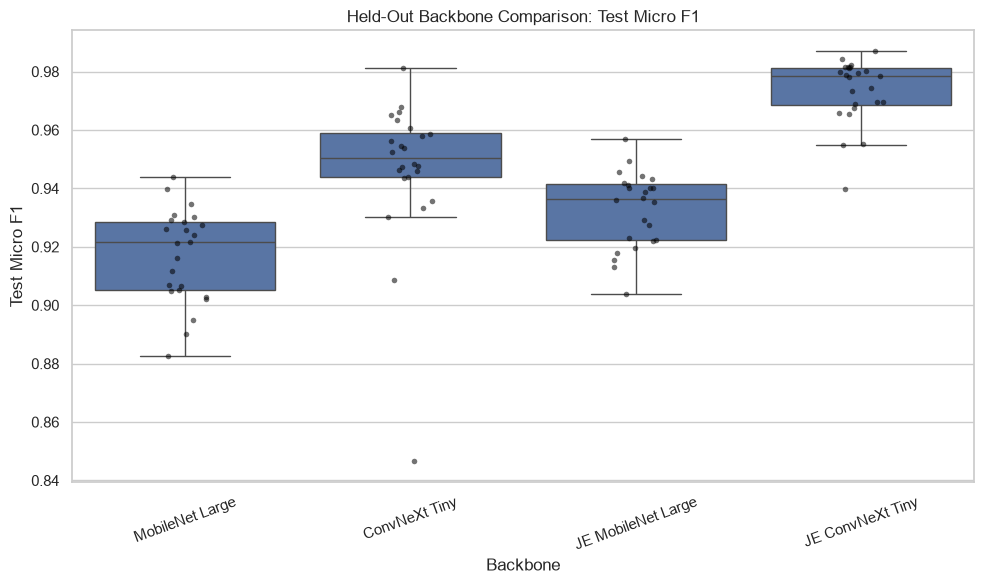

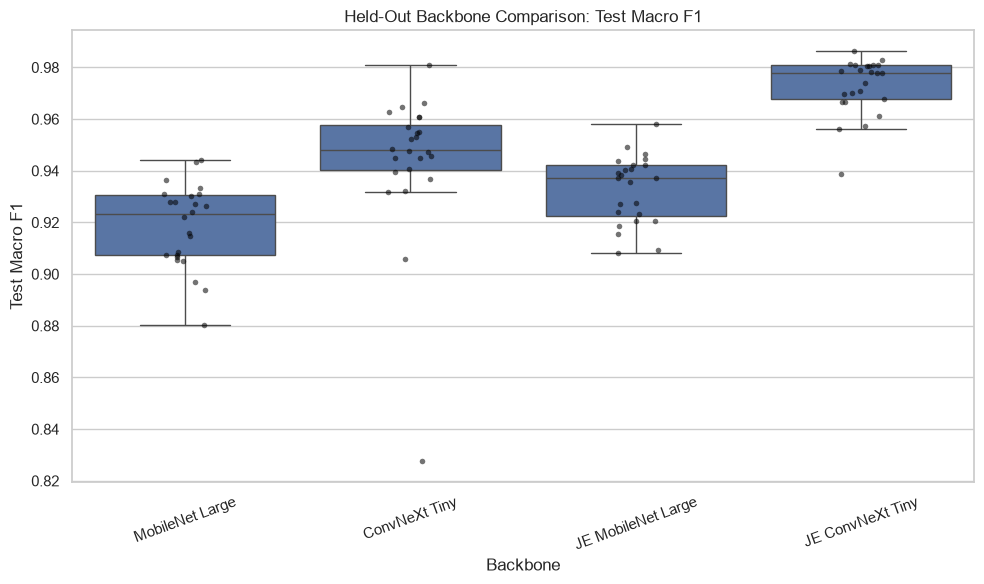

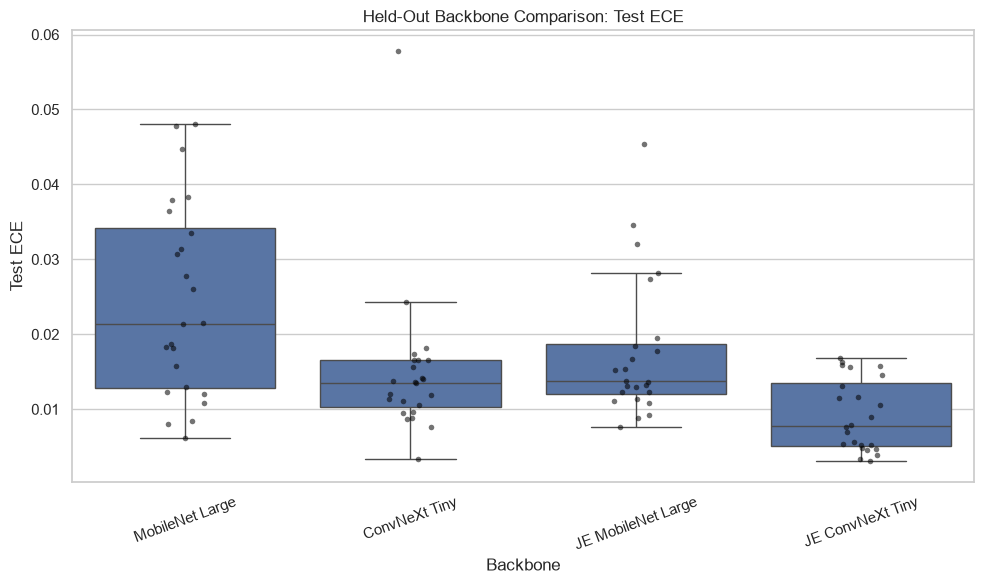

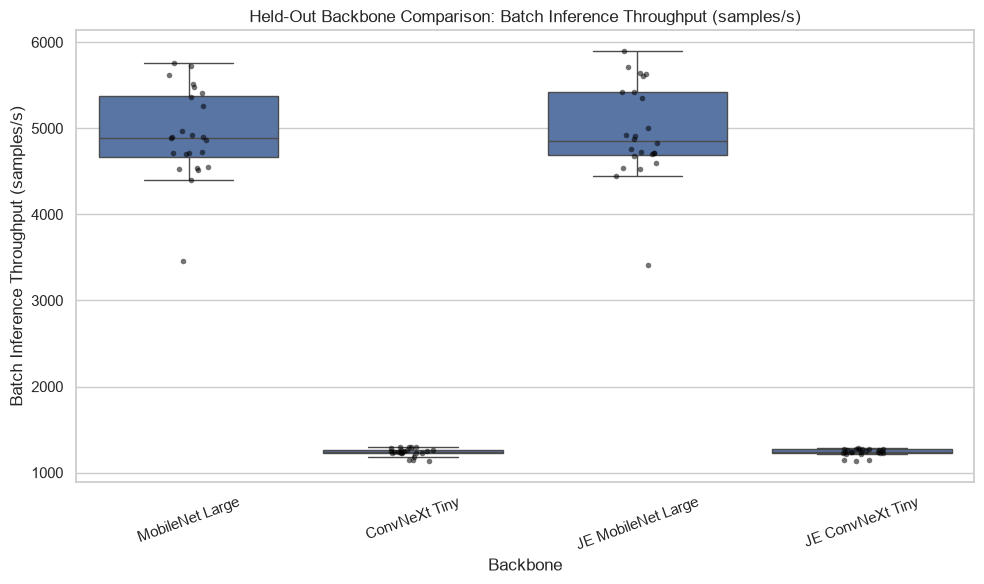

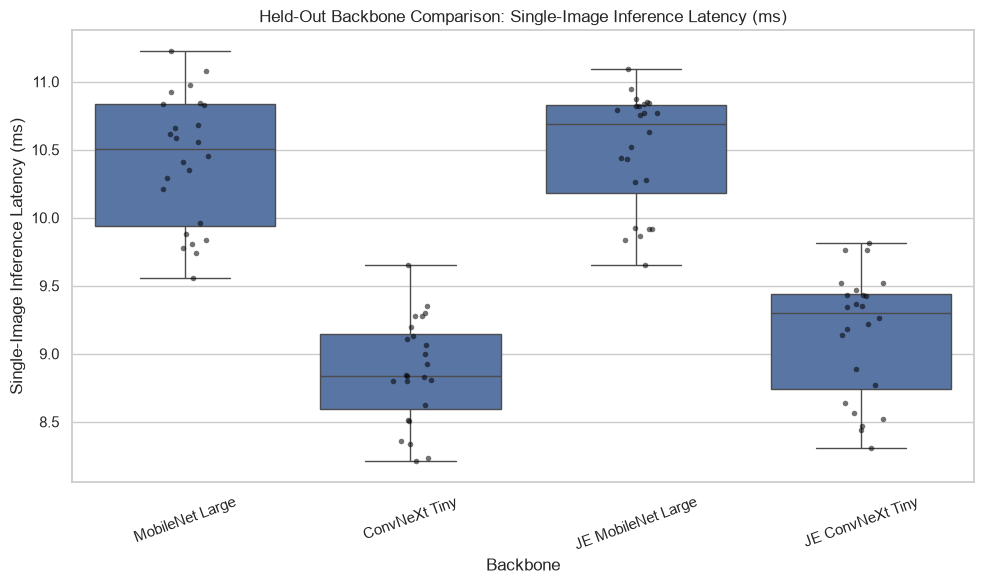

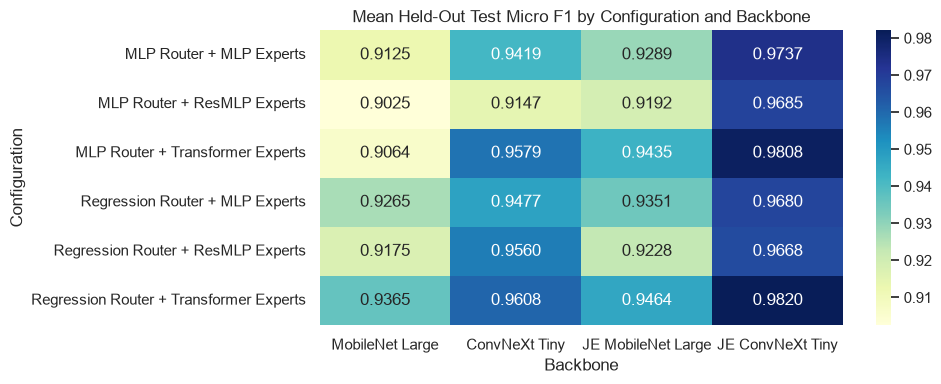

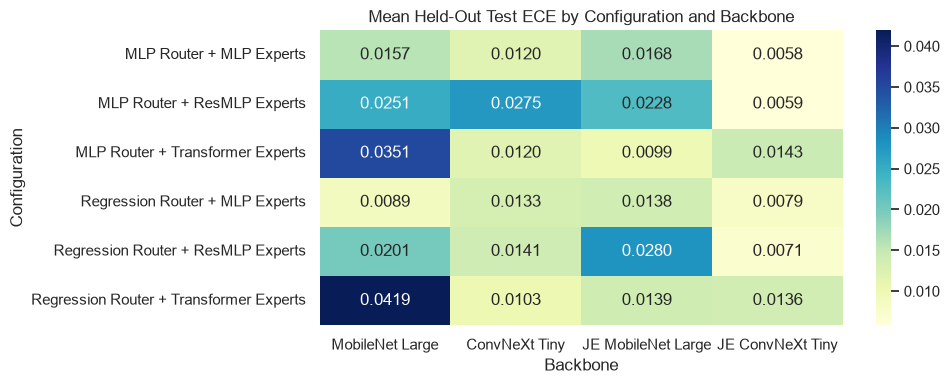

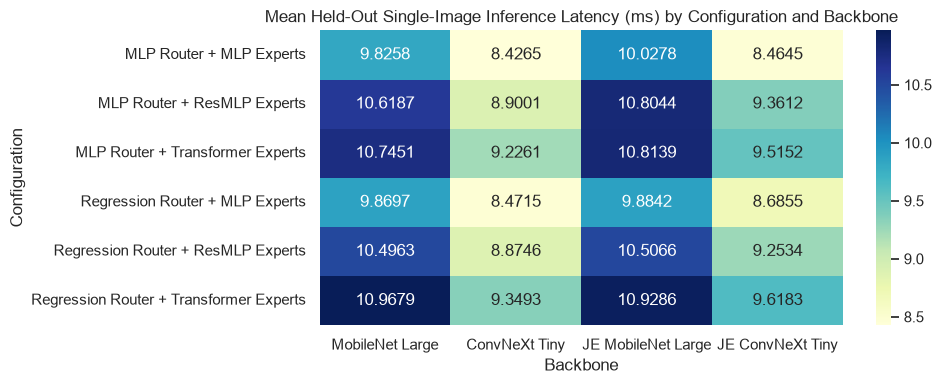

In [5]:
sns.set_theme(style='whitegrid')
PLOT_METRICS = [metric for metric in ['Test Micro F1', 'Test Macro F1', 'Test ECE', 'Batch Inference Throughput (samples/s)', 'Single-Image Inference Latency (ms)'] if metric in results_df.columns]
for metric in PLOT_METRICS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, fliersize=0)
    sns.stripplot(data=results_df, x='Backbone', y=metric, order=BACKBONE_ORDER, color='black', alpha=0.55, size=4)
    plt.title(f'Held-Out Backbone Comparison: {metric}')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

for metric in [name for name in ['Test Micro F1', 'Test ECE', 'Single-Image Inference Latency (ms)'] if name in results_df.columns]:
    pivot = results_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean', observed=False).reindex(columns=BACKBONE_ORDER)
    plt.figure(figsize=(10, max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
    plt.title(f'Mean Held-Out {metric} by Configuration and Backbone')
    plt.tight_layout()
    plt.show()

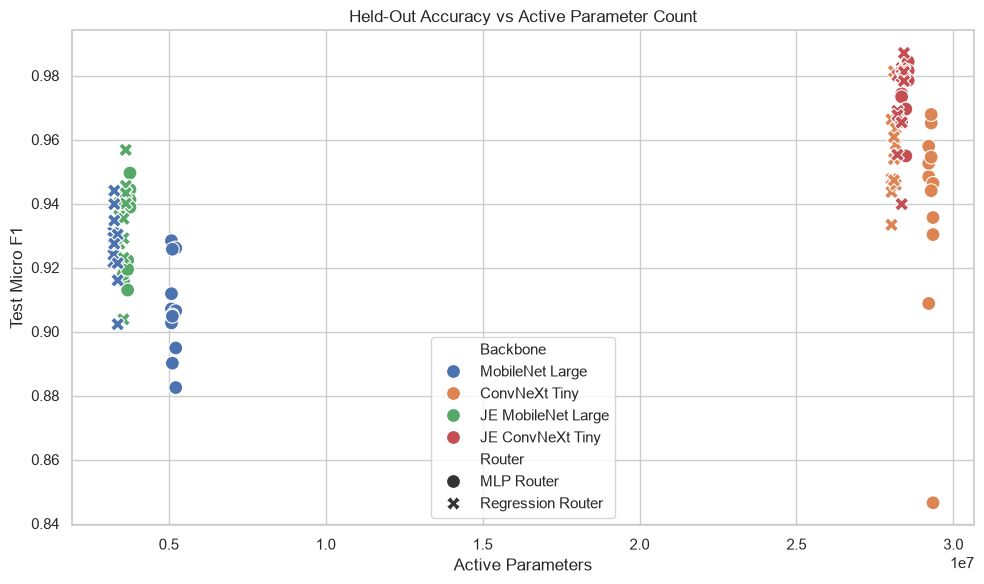

In [6]:
if {'Active Parameters', 'Test Micro F1'}.issubset(results_df.columns):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=results_df, x='Active Parameters', y='Test Micro F1', hue='Backbone', style='Router', hue_order=BACKBONE_ORDER, s=100)
    plt.title('Held-Out Accuracy vs Active Parameter Count')
    plt.tight_layout()
    plt.show()